In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [ ]:
df = pd.read_csv('data/train.csv')

In [5]:
df.shape

(593994, 13)

In [6]:
df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [7]:
# Nie ma nulli 
df.isnull().sum()

id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

In [8]:
# nie ma zduplikowanych wierszy
df.duplicated().sum()

0

In [9]:
df['loan_to_income'] = df['loan_amount'] / df['annual_income']

In [10]:
df

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,loan_to_income
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0,0.086094
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0,0.207757
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0,0.343080
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0,0.099929
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0,0.477883
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,593989,23004.26,0.152,703,20958.37,10.92,Female,Single,High School,Employed,Business,C3,1.0,0.911065
593990,593990,35289.43,0.105,559,3257.24,14.62,Male,Single,Bachelor's,Employed,Debt consolidation,F5,1.0,0.092301
593991,593991,47112.64,0.072,675,929.27,14.13,Female,Married,Bachelor's,Employed,Debt consolidation,C1,1.0,0.019724
593992,593992,76748.44,0.067,740,16290.40,9.87,Male,Single,Bachelor's,Employed,Debt consolidation,B2,1.0,0.212257


In [11]:
# podstawowe statystyki
cols = ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'loan_to_income']

desc = df[cols].describe()

desc.loc['median'] = df[cols].median()
desc.loc['mode'] = df[cols].mode().iloc[0]

desc = desc.drop('count')

desc

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_to_income
mean,48212.202976,0.120696,680.916009,15020.297629,12.356345,0.427574
std,26711.942078,0.068573,55.424956,6926.530568,2.008959,0.366041
min,6002.430000,0.011000,395.000000,500.090000,3.200000,0.002491
25%,27934.400000,0.072000,646.000000,10279.620000,10.990000,0.194734
50%,46557.680000,0.096000,682.000000,15000.220000,12.370000,0.322538
75%,60981.320000,0.156000,719.000000,18858.580000,13.680000,0.536990
max,393381.740000,0.627000,849.000000,48959.950000,20.990000,5.461143
median,46557.680000,0.096000,682.000000,15000.220000,12.370000,0.322538
mode,51351.710000,0.090000,678.000000,12892.250000,12.310000,1.000000


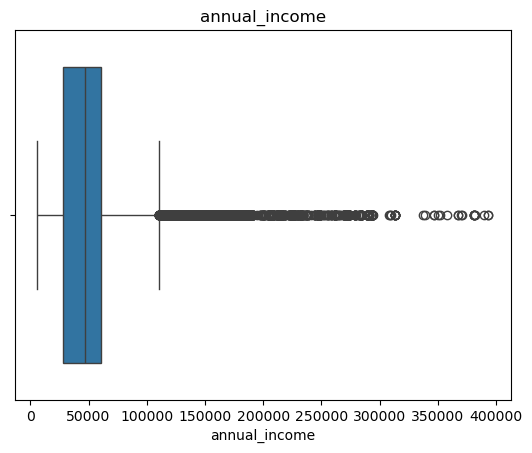

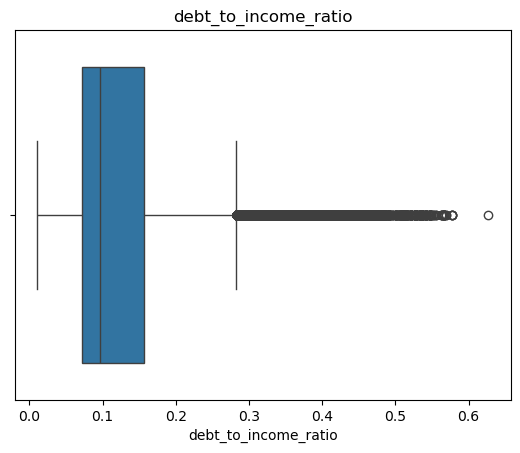

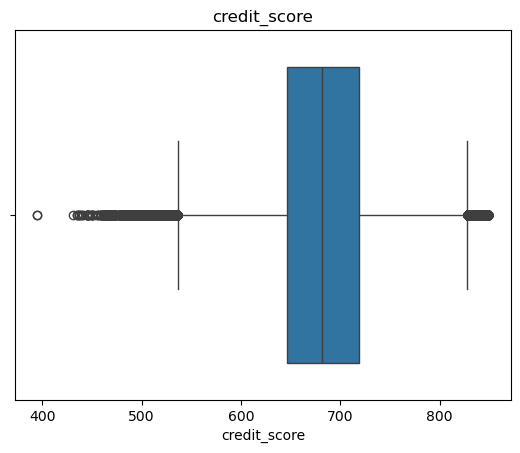

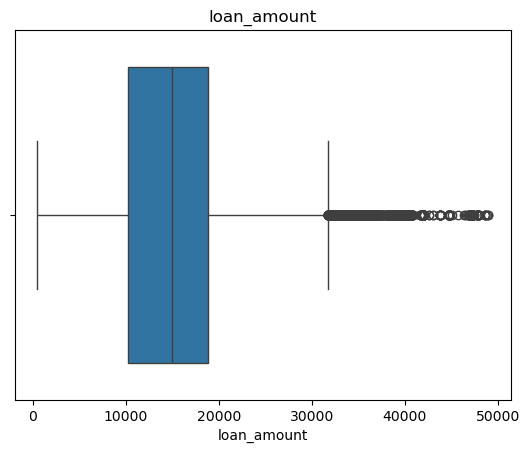

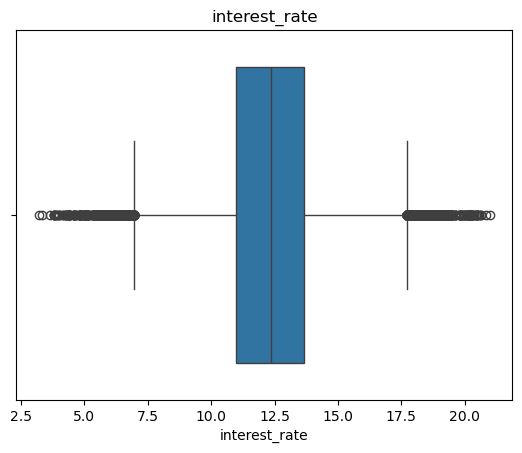

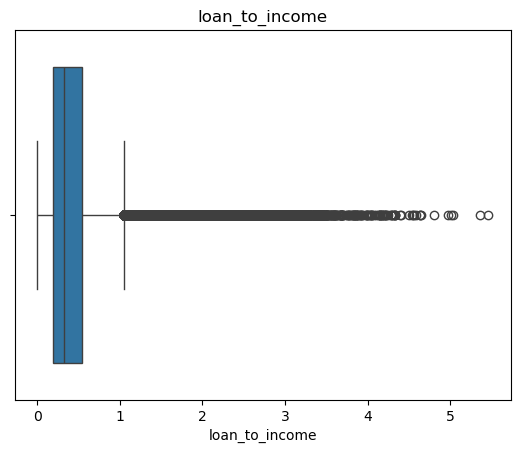

In [12]:
for c in cols:
    sns.boxplot(x=df[c])
    plt.title(c)
    plt.show()

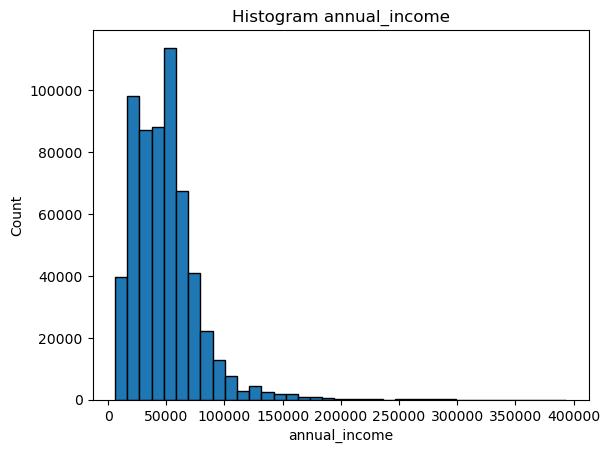

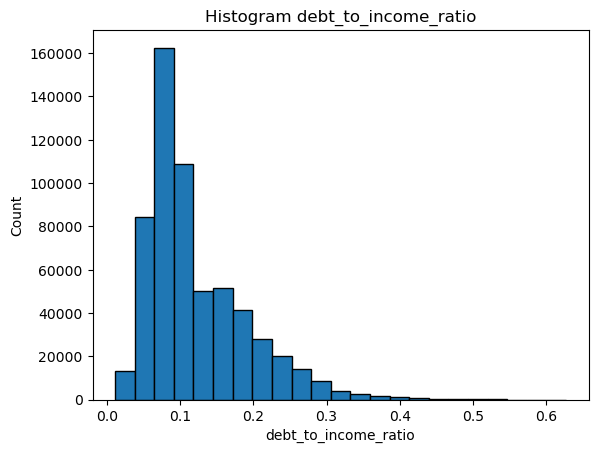

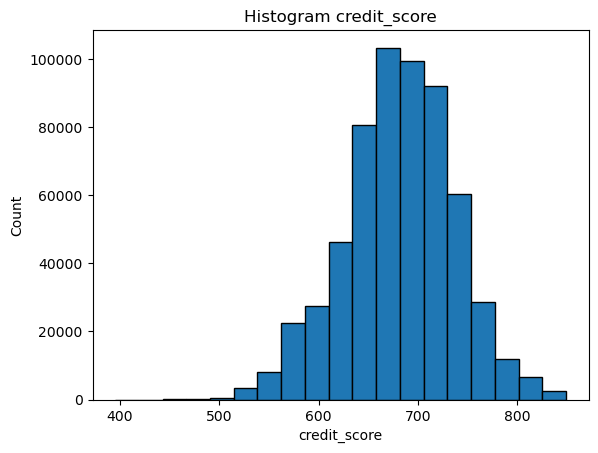

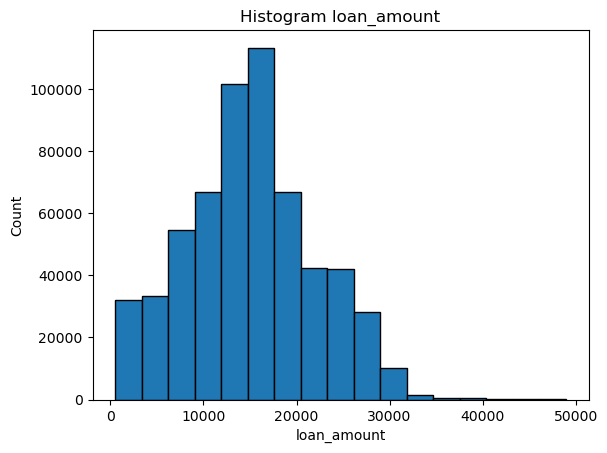

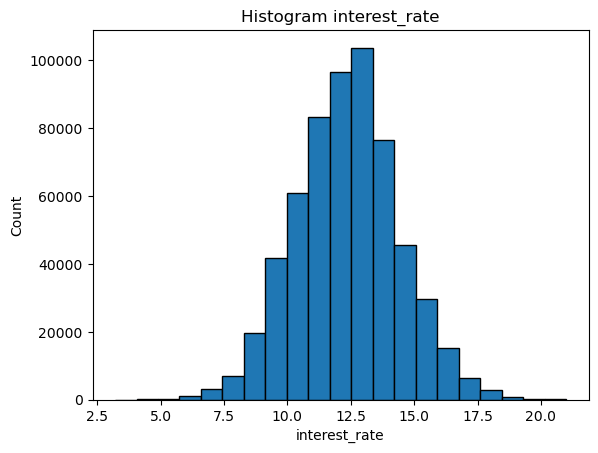

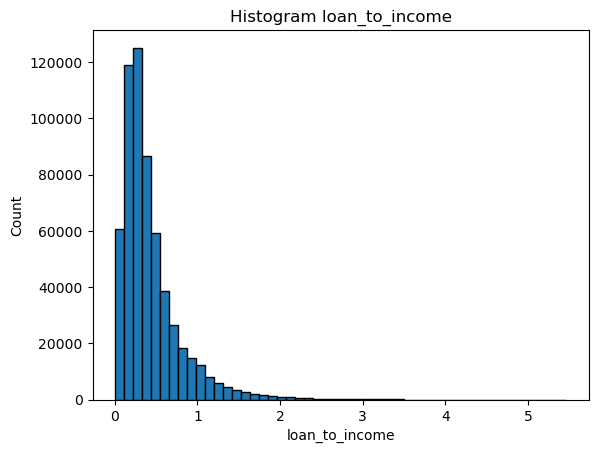

In [13]:
for c in cols:
    Q1 = df[c].quantile(0.25)
    Q3 = df[c].quantile(0.75)
    IQR = Q3 - Q1
    h = 2.64 * IQR * pow(len(df[c]),(-1/3))  
    num_bins = int(((df[c].max()-df[c].min())/h)/10)

    plt.hist(df[c], bins=num_bins, edgecolor='black')
    plt.title('Histogram ' + c)
    plt.xlabel(c)
    plt.ylabel('Count')
    plt.show()

In [14]:
# macierz korelacji
# dość silna korelacja interest_rate i credit_score
correlation = df[cols].corr()
correlation

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_to_income
annual_income,1.000000,0.000553,0.001509,-0.003407,-0.002507,-0.572122
debt_to_income_ratio,0.000553,1.000000,-0.061617,-0.008236,0.030316,-0.002835
credit_score,0.001509,-0.061617,1.000000,-0.005761,-0.538335,-0.007187
loan_amount,-0.003407,-0.008236,-0.005761,1.000000,-0.001174,0.546287
interest_rate,-0.002507,0.030316,-0.538335,-0.001174,1.000000,0.004983
loan_to_income,-0.572122,-0.002835,-0.007187,0.546287,0.004983,1.000000


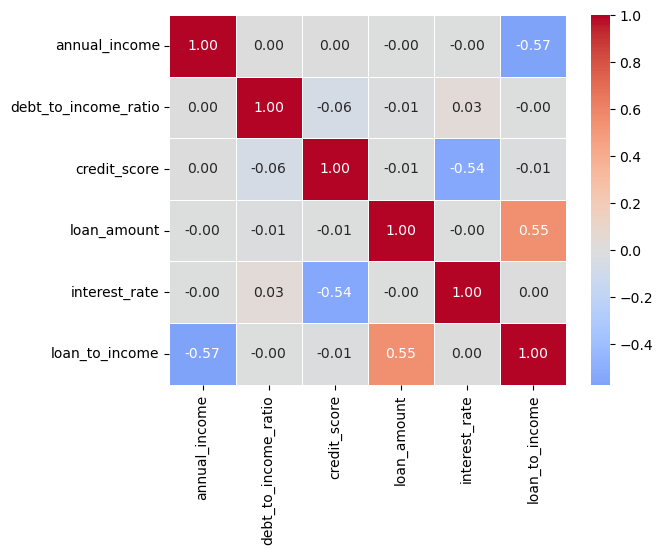

In [15]:
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.show()

In [16]:
cols2 =[]
for c in cols:
    Q1 = df[c].quantile(0.25)
    Q3 = df[c].quantile(0.75)
    IQR = Q3 - Q1
    
    h = 2.64 * IQR * pow(len(df[c]),(-1/3)) * 20
    
    df[c+'_label'] = ((df[c] - df[c].min()) / h).astype(int)    
    cols2.append(c+'_label')
    print(c, 'buckets number', set(df[c+'_label']))
cols2.extend(['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade'])

annual_income buckets number {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18}
debt_to_income_ratio buckets number {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11}
credit_score buckets number {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
loan_amount buckets number {0, 1, 2, 3, 4, 5, 6, 7, 8}
interest_rate buckets number {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10}
loan_to_income buckets number {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25}


In [17]:
cols2

['annual_income_label',
 'debt_to_income_ratio_label',
 'credit_score_label',
 'loan_amount_label',
 'interest_rate_label',
 'loan_to_income_label',
 'gender',
 'marital_status',
 'education_level',
 'employment_status',
 'loan_purpose',
 'grade_subgrade']

In [18]:
df

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,loan_to_income,annual_income_label,debt_to_income_ratio_label,credit_score_label,loan_amount_label,interest_rate_label,loan_to_income_label
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0,0.086094,1,1,7,0,6,0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0,0.207757,0,2,5,0,5,0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0,0.343080,2,1,6,3,3,1
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0,0.099929,1,1,3,0,7,0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0,0.477883,0,0,5,2,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,593989,23004.26,0.152,703,20958.37,10.92,Female,Single,High School,Employed,Business,C3,1.0,0.911065,0,2,6,3,4,4
593990,593990,35289.43,0.105,559,3257.24,14.62,Male,Single,Bachelor's,Employed,Debt consolidation,F5,1.0,0.092301,1,1,3,0,6,0
593991,593991,47112.64,0.072,675,929.27,14.13,Female,Married,Bachelor's,Employed,Debt consolidation,C1,1.0,0.019724,1,1,6,0,6,0
593992,593992,76748.44,0.067,740,16290.40,9.87,Male,Single,Bachelor's,Employed,Debt consolidation,B2,1.0,0.212257,3,1,7,2,3,0


In [19]:
df_paid = df.query('loan_paid_back==1')

In [20]:
df_paid

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,loan_to_income,annual_income_label,debt_to_income_ratio_label,credit_score_label,loan_amount_label,interest_rate_label,loan_to_income_label
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0,0.086094,1,1,7,0,6,0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0,0.343080,2,1,6,3,3,1
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0,0.099929,1,1,3,0,7,0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0,0.477883,0,0,5,2,4,2
5,5,44940.30,0.058,653,12159.92,12.24,Male,Single,Bachelor's,Employed,Other,D1,1.0,0.270579,1,0,5,2,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,593989,23004.26,0.152,703,20958.37,10.92,Female,Single,High School,Employed,Business,C3,1.0,0.911065,0,2,6,3,4,4
593990,593990,35289.43,0.105,559,3257.24,14.62,Male,Single,Bachelor's,Employed,Debt consolidation,F5,1.0,0.092301,1,1,3,0,6,0
593991,593991,47112.64,0.072,675,929.27,14.13,Female,Married,Bachelor's,Employed,Debt consolidation,C1,1.0,0.019724,1,1,6,0,6,0
593992,593992,76748.44,0.067,740,16290.40,9.87,Male,Single,Bachelor's,Employed,Debt consolidation,B2,1.0,0.212257,3,1,7,2,3,0


In [21]:
# stosunek osób, które spłaciły w danej kategorii do ogółu osób w tej kategorii; im większa wartość tym "bezpieczniejsza" grupa 
# jeśli >1 -> grupa spłaca kredyt częściej niż średnio w populacji
# jeśli =1 -> grupa spłaca kredyt w proporcji w jakiej należy do populacji
# jeśli <1 -> grupa spłaca kredyt rzadziej niż średnio w populacji

# 11  NaN w debt_to_income_ratio_label, bo z osób, które spłaciły kredyt, nikt nie należy do tej grupy

for c in cols2:
    ratio =  df_paid[c].value_counts(normalize=True) / df[c].value_counts(normalize=True)
    print(ratio, '\n')

annual_income_label
0     0.996750
1     0.994280
2     1.002232
3     1.014834
4     1.025324
5     0.997880
6     0.952151
7     0.946803
8     0.975451
9     0.834565
10    0.938885
11    0.919724
12    0.938885
13    0.972719
14    0.910434
15    1.251847
16    0.834565
17    0.938885
18    0.973659
Name: proportion, dtype: float64 

debt_to_income_ratio_label
0     1.153647
1     1.088395
2     1.006571
3     0.769164
4     0.603967
5     0.615597
6     0.554262
7     0.442031
8     0.364787
9     0.338510
10    0.171822
11         NaN
Name: proportion, dtype: float64 

credit_score_label
0    0.751108
1    0.839474
2    0.696821
3    0.786593
4    0.819943
5    0.908923
6    1.037365
7    1.128160
8    1.193219
9    1.201817
Name: proportion, dtype: float64 

loan_amount_label
2    0.996346
3    0.992509
1    1.015104
4    1.001616
0    0.991899
5    1.020611
6    0.950792
7    0.906022
8    0.876293
Name: proportion, dtype: float64 

interest_rate_label
5     1.004701
4     1.05

In [22]:
# ~80% jest spłaconych kredytów, jest niezrównowazenie między spłaconymi i nie
df['loan_paid_back'].value_counts(normalize=True)

loan_paid_back
1.0    0.79882
0.0    0.20118
Name: proportion, dtype: float64

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   id                          593994 non-null  int64  
 1   annual_income               593994 non-null  float64
 2   debt_to_income_ratio        593994 non-null  float64
 3   credit_score                593994 non-null  int64  
 4   loan_amount                 593994 non-null  float64
 5   interest_rate               593994 non-null  float64
 6   gender                      593994 non-null  object 
 7   marital_status              593994 non-null  object 
 8   education_level             593994 non-null  object 
 9   employment_status           593994 non-null  object 
 10  loan_purpose                593994 non-null  object 
 11  grade_subgrade              593994 non-null  object 
 12  loan_paid_back              593994 non-null  float64
 13  loan_to_income

In [24]:
df.nunique()

id                            593994
annual_income                 119728
debt_to_income_ratio             526
credit_score                     399
loan_amount                   111570
interest_rate                   1454
gender                             3
marital_status                     4
education_level                    5
employment_status                  5
loan_purpose                       8
grade_subgrade                    30
loan_paid_back                     2
loan_to_income                591310
annual_income_label               19
debt_to_income_ratio_label        12
credit_score_label                10
loan_amount_label                  9
interest_rate_label               11
loan_to_income_label              26
dtype: int64

In [25]:
cat_col = df.select_dtypes(include='object').columns.tolist()
num_col = df.select_dtypes(include='number').columns.tolist()

In [26]:
num_col

['id',
 'annual_income',
 'debt_to_income_ratio',
 'credit_score',
 'loan_amount',
 'interest_rate',
 'loan_paid_back',
 'loan_to_income',
 'annual_income_label',
 'debt_to_income_ratio_label',
 'credit_score_label',
 'loan_amount_label',
 'interest_rate_label',
 'loan_to_income_label']

In [27]:
df[cat_col].nunique()

gender                3
marital_status        4
education_level       5
employment_status     5
loan_purpose          8
grade_subgrade       30
dtype: int64

In [28]:
df['gender'].value_counts(normalize=True)

gender
Female    0.515451
Male      0.478273
Other     0.006276
Name: proportion, dtype: float64

In [29]:
df['marital_status'].value_counts()

marital_status
Single      288843
Married     277239
Divorced     21312
Widowed       6600
Name: count, dtype: int64

In [30]:
df['education_level'].value_counts()

education_level
Bachelor's     279606
High School    183592
Master's        93097
Other           26677
PhD             11022
Name: count, dtype: int64

In [31]:
df['employment_status'].value_counts()

employment_status
Employed         450645
Unemployed        62485
Self-employed     52480
Retired           16453
Student           11931
Name: count, dtype: int64

In [32]:
df['loan_purpose'].value_counts()

loan_purpose
Debt consolidation    324695
Other                  63874
Car                    58108
Home                   44118
Education              36641
Business               35303
Medical                22806
Vacation                8449
Name: count, dtype: int64

In [33]:
df['grade_subgrade'].value_counts()

grade_subgrade
C3    58695
C4    55957
C2    54443
C1    53363
C5    53317
D1    37029
D3    36694
D4    35097
D2    34432
D5    32101
B2    15167
B1    14344
B5    13937
B3    13926
B4    13877
E4     8036
E3     7075
E1     6891
E2     6372
E5     6084
F5     5947
F4     5535
F1     5534
F2     5203
F3     5082
A5     2471
A3     2066
A2     2018
A4     1701
A1     1600
Name: count, dtype: int64

In [34]:
df_ex = df.copy()
df_ex['grade_letter'] = df['grade_subgrade'].str[0]
df_ex['subgrade_num'] = df['grade_subgrade'].str[1:].astype(int)

In [35]:
del df_ex['id']

In [36]:
del df_ex['grade_subgrade']

In [30]:
df_ex

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,loan_paid_back,loan_to_income,grade_letter,subgrade_num
0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,1.0,0.086094,C,3
1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,0.0,0.207757,D,3
2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,1.0,0.343080,C,5
3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,1.0,0.099929,F,1
4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,1.0,0.477883,D,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,23004.26,0.152,703,20958.37,10.92,Female,Single,High School,Employed,Business,1.0,0.911065,C,3
593990,35289.43,0.105,559,3257.24,14.62,Male,Single,Bachelor's,Employed,Debt consolidation,1.0,0.092301,F,5
593991,47112.64,0.072,675,929.27,14.13,Female,Married,Bachelor's,Employed,Debt consolidation,1.0,0.019724,C,1
593992,76748.44,0.067,740,16290.40,9.87,Male,Single,Bachelor's,Employed,Debt consolidation,1.0,0.212257,B,2


In [37]:
grade_map = {'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6}
df_ex['grade_letter_rank'] = df_ex['grade_letter'].map(grade_map)

In [38]:
del df_ex['grade_letter']

In [39]:
df_ex

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,loan_paid_back,loan_to_income,annual_income_label,debt_to_income_ratio_label,credit_score_label,loan_amount_label,interest_rate_label,loan_to_income_label,subgrade_num,grade_letter_rank
0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,1.0,0.086094,1,1,7,0,6,0,3,3
1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,0.0,0.207757,0,2,5,0,5,0,3,4
2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,1.0,0.343080,2,1,6,3,3,1,5,3
3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,1.0,0.099929,1,1,3,0,7,0,1,6
4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,1.0,0.477883,0,0,5,2,4,2,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,23004.26,0.152,703,20958.37,10.92,Female,Single,High School,Employed,Business,1.0,0.911065,0,2,6,3,4,4,3,3
593990,35289.43,0.105,559,3257.24,14.62,Male,Single,Bachelor's,Employed,Debt consolidation,1.0,0.092301,1,1,3,0,6,0,5,6
593991,47112.64,0.072,675,929.27,14.13,Female,Married,Bachelor's,Employed,Debt consolidation,1.0,0.019724,1,1,6,0,6,0,1,3
593992,76748.44,0.067,740,16290.40,9.87,Male,Single,Bachelor's,Employed,Debt consolidation,1.0,0.212257,3,1,7,2,3,0,2,2


In [40]:
df_ex['education_level'].value_counts()

education_level
Bachelor's     279606
High School    183592
Master's        93097
Other           26677
PhD             11022
Name: count, dtype: int64

In [41]:
education_ranking = {"PhD": 5, "Master's": 4, "Bachelor's": 3, "High School": 2, "Other": 1}
df_ex['education_rank'] = df_ex['education_level'].map(education_ranking)

In [42]:
del df_ex['education_level']

In [43]:
df_ex

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,employment_status,loan_purpose,loan_paid_back,loan_to_income,annual_income_label,debt_to_income_ratio_label,credit_score_label,loan_amount_label,interest_rate_label,loan_to_income_label,subgrade_num,grade_letter_rank,education_rank
0,29367.99,0.084,736,2528.42,13.67,Female,Single,Self-employed,Other,1.0,0.086094,1,1,7,0,6,0,3,3,2
1,22108.02,0.166,636,4593.10,12.92,Male,Married,Employed,Debt consolidation,0.0,0.207757,0,2,5,0,5,0,3,4,4
2,49566.20,0.097,694,17005.15,9.76,Male,Single,Employed,Debt consolidation,1.0,0.343080,2,1,6,3,3,1,5,3,2
3,46858.25,0.065,533,4682.48,16.10,Female,Single,Employed,Debt consolidation,1.0,0.099929,1,1,3,0,7,0,1,6,2
4,25496.70,0.053,665,12184.43,10.21,Male,Married,Employed,Other,1.0,0.477883,0,0,5,2,4,2,1,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,23004.26,0.152,703,20958.37,10.92,Female,Single,Employed,Business,1.0,0.911065,0,2,6,3,4,4,3,3,2
593990,35289.43,0.105,559,3257.24,14.62,Male,Single,Employed,Debt consolidation,1.0,0.092301,1,1,3,0,6,0,5,6,3
593991,47112.64,0.072,675,929.27,14.13,Female,Married,Employed,Debt consolidation,1.0,0.019724,1,1,6,0,6,0,1,3,3
593992,76748.44,0.067,740,16290.40,9.87,Male,Single,Employed,Debt consolidation,1.0,0.212257,3,1,7,2,3,0,2,2,3


In [44]:
df_ex = pd.get_dummies(df_ex, columns=['gender', 'marital_status', 'employment_status', 'loan_purpose'], drop_first=True)

In [45]:
df_ex

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back,loan_to_income,annual_income_label,debt_to_income_ratio_label,credit_score_label,...,employment_status_Self-employed,employment_status_Student,employment_status_Unemployed,loan_purpose_Car,loan_purpose_Debt consolidation,loan_purpose_Education,loan_purpose_Home,loan_purpose_Medical,loan_purpose_Other,loan_purpose_Vacation
0,29367.99,0.084,736,2528.42,13.67,1.0,0.086094,1,1,7,...,True,False,False,False,False,False,False,False,True,False
1,22108.02,0.166,636,4593.10,12.92,0.0,0.207757,0,2,5,...,False,False,False,False,True,False,False,False,False,False
2,49566.20,0.097,694,17005.15,9.76,1.0,0.343080,2,1,6,...,False,False,False,False,True,False,False,False,False,False
3,46858.25,0.065,533,4682.48,16.10,1.0,0.099929,1,1,3,...,False,False,False,False,True,False,False,False,False,False
4,25496.70,0.053,665,12184.43,10.21,1.0,0.477883,0,0,5,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,23004.26,0.152,703,20958.37,10.92,1.0,0.911065,0,2,6,...,False,False,False,False,False,False,False,False,False,False
593990,35289.43,0.105,559,3257.24,14.62,1.0,0.092301,1,1,3,...,False,False,False,False,True,False,False,False,False,False
593991,47112.64,0.072,675,929.27,14.13,1.0,0.019724,1,1,6,...,False,False,False,False,True,False,False,False,False,False
593992,76748.44,0.067,740,16290.40,9.87,1.0,0.212257,3,1,7,...,False,False,False,False,True,False,False,False,False,False


In [46]:
X = df_ex.drop(['loan_paid_back'], axis=1)
y = df_ex['loan_paid_back']

In [ ]:
import optuna
import xgboost as xgb
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

def objective_xgb(trial, X, y):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'tree_method': 'hist',
        'random_state': 42,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'lambda': trial.suggest_float('lambda', 1e-8, 10.0, log=True),  # L2
        'alpha': trial.suggest_float('alpha', 1e-8, 10.0, log=True),    # L1
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
        dval = xgb.DMatrix(X_val, label=y_val, enable_categorical=True)

        model = xgb.train(
            params,
            dtrain,
            num_boost_round=1000,
            evals=[(dval, 'valid')],
            early_stopping_rounds=50,
            verbose_eval=False
        )

        preds = model.predict(dval)
        scores.append(roc_auc_score(y_val, preds))

    return np.mean(scores)

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(lambda trial: objective_xgb(trial, X, y), n_trials=50)

print("Najlepszy wynik AUC dla XGBoost:", study_xgb.best_value)
print("Najlepsze parametry:", study_xgb.best_params)

[I 2026-03-26 15:32:02,279] A new study created in memory with name: no-name-76914729-225c-41cf-a8f4-872ede282786
[I 2026-03-26 15:33:31,942] Trial 0 finished with value: 0.9208005989242395 and parameters: {'learning_rate': 0.02543669710551824, 'max_depth': 6, 'min_child_weight': 12, 'subsample': 0.6701386158276659, 'colsample_bytree': 0.6147559645826912, 'gamma': 0.0001434856727162418, 'lambda': 1.6368884443571117, 'alpha': 2.7863891478060586e-07}. Best is trial 0 with value: 0.9208005989242395.
[I 2026-03-26 15:33:52,868] Trial 1 finished with value: 0.9199380811987689 and parameters: {'learning_rate': 0.09846761637420594, 'max_depth': 12, 'min_child_weight': 20, 'subsample': 0.9380861011971343, 'colsample_bytree': 0.7007443413034817, 'gamma': 0.02047429501088965, 'lambda': 0.6589124477509105, 'alpha': 5.770245723763107e-06}. Best is trial 0 with value: 0.9208005989242395.
[I 2026-03-26 15:35:15,553] Trial 2 finished with value: 0.9173122400969344 and parameters: {'learning_rate': 0.

In [47]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score

X = df_ex.drop(['loan_paid_back'], axis=1)
y = df_ex['loan_paid_back']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
    dval = xgb.DMatrix(X_val, label=y_val, enable_categorical=True)
    
    params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'tree_method': 'hist',
    'learning_rate': 0.014366,
    'max_depth': 10,
    'min_child_weight': 10,
    'subsample': 0.8629,
    'colsample_bytree': 0.5000,
    'gamma': 0.0011,
    'lambda': 1.45e-08,
    'alpha': 1.36e-08,
    'random_state': 42
}
    
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        evals=[(dtrain, 'train'), (dval, 'valid')],
        early_stopping_rounds=50,
        verbose_eval=100
    )

    oof_preds[val_idx] = model.predict(dval)
    models.append(model)
       

[0]	train-auc:0.90617	valid-auc:0.90484
[100]	train-auc:0.92073	valid-auc:0.91790
[200]	train-auc:0.92361	valid-auc:0.91932
[300]	train-auc:0.92597	valid-auc:0.92031
[400]	train-auc:0.92818	valid-auc:0.92099
[500]	train-auc:0.92986	valid-auc:0.92136
[600]	train-auc:0.93152	valid-auc:0.92166
[700]	train-auc:0.93304	valid-auc:0.92188
[800]	train-auc:0.93477	valid-auc:0.92211
[900]	train-auc:0.93626	valid-auc:0.92221
[999]	train-auc:0.93768	valid-auc:0.92228
[0]	train-auc:0.90636	valid-auc:0.90418
[100]	train-auc:0.92093	valid-auc:0.91701
[200]	train-auc:0.92368	valid-auc:0.91858
[300]	train-auc:0.92612	valid-auc:0.91977
[400]	train-auc:0.92833	valid-auc:0.92059
[500]	train-auc:0.93000	valid-auc:0.92100
[600]	train-auc:0.93150	valid-auc:0.92135
[700]	train-auc:0.93300	valid-auc:0.92162
[800]	train-auc:0.93455	valid-auc:0.92178
[900]	train-auc:0.93609	valid-auc:0.92191
[999]	train-auc:0.93749	valid-auc:0.92199
[0]	train-auc:0.90679	valid-auc:0.90309
[100]	train-auc:0.92124	valid-auc:0.9158

In [48]:
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Obliczamy ogólne AUC
auc_total = roc_auc_score(y, oof_preds)
print(f"Final OOF AUC: {auc_total:.4f}")

# 2. Zamieniamy prawdopodobieństwa na klasy (próg 0.5)
# Możesz eksperymentować z tym progiem!
oof_classes = (oof_preds > 0.5).astype(int)

print("\nRaport klasyfikacji:")
print(classification_report(y, oof_classes))

Final OOF AUC: 0.9213

Raport klasyfikacji:
              precision    recall  f1-score   support

         0.0       0.88      0.61      0.72    119500
         1.0       0.91      0.98      0.94    474494

    accuracy                           0.90    593994
   macro avg       0.90      0.79      0.83    593994
weighted avg       0.90      0.90      0.90    593994



In [2]:

import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score

X = df_ex.drop(['loan_paid_back'], axis=1)
y = df_ex['loan_paid_back']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
    dval = xgb.DMatrix(X_val, label=y_val, enable_categorical=True)
    
    best_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'tree_method': 'hist',
    'learning_rate': 0.014366,
    'max_depth': 10,
    'min_child_weight': 10,
    'subsample': 0.8629,
    'colsample_bytree': 0.5000,
    'gamma': 0.0011,
    'lambda': 1.45e-08,
    'alpha': 1.36e-08,
    'random_state': 42
}
    
    model = xgb.train(
        best_params,
        dtrain,
        num_boost_round=1000,
        evals=[(dtrain, 'train'), (dval, 'valid')],
        early_stopping_rounds=50,
        verbose_eval=100
    )

    oof_preds[val_idx] = model.predict(dval)
    models.append(model)
       

NameError: name 'df_ex' is not defined

In [34]:
model.save_model('loan_repayment_model_day1.json')

In [ ]:
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score

X = df_ex.drop(['loan_paid_back'], axis=1)
y = df_ex['loan_paid_back']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
models = []

params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'max_depth': 6,
    'num_leaves': 63,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'feature_fraction': 0.8,
    'random_state': 42,
    'verbosity': -1
}

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

 
    train_data = lgb.Dataset(X_train, label=y_train)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)
    
    # Trenowanie modelu
    model = lgb.train(
        params,
        train_data,
        num_boost_round=1000,
        valid_sets=[train_data, val_data],
        valid_names=['train', 'valid'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(period=100)
        ]
    )

    # Zapisywanie predykcji (w LGBM model.predict zwraca prawdopodobieństwa dla klasyfikacji binarnej)
    oof_preds[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)
    models.append(model)

# Finalny wynik OOF
full_auc = roc_auc_score(y, oof_preds)
print(f"\nOverall OOF AUC: {full_auc:.4f}")

In [ ]:
from catboost import CatBoostClassifier, Pool
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

X = df_ex.drop(['loan_paid_back'], axis=1)
y = df_ex['loan_paid_back']

# Opcjonalnie: zidentyfikuj kolumny kategoryczne (ich indeksy lub nazwy)
# CatBoost sam je obsłuży, jeśli wskażesz je w parametrze cat_features
cat_features = list(X.select_dtypes(include=['category', 'object']).columns)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Tworzymy Pool - specyficzny format CatBoost
    train_pool = Pool(X_train, y_train, cat_features=cat_features)
    val_pool = Pool(X_val, y_val, cat_features=cat_features)
    
    model = CatBoostClassifier(
        iterations=1000,          # odpowiednik num_boost_round
        learning_rate=0.05,
        depth=6,                  # odpowiednik max_depth
        eval_metric='AUC',
        random_seed=42,
        verbose=100,              # co ile iteracji wypisywać logi
        early_stopping_rounds=50,
        use_best_model=True       # przywraca najlepsze drzewo po treningu
    )
    
    model.fit(train_pool, eval_set=val_pool)

    # Predykcja prawdopodobieństwa dla klasy 1
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    models.append(model)

print(f"\nOverall OOF AUC: {roc_auc_score(y, oof_preds):.4f}")

In [ ]:
import optuna
import lightgbm as lgb
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

def objective(trial, X, y):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': 42,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 255),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 100),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
    }

    # 2. Walidacja krzyżowa wewnątrz Optuny
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42) # 3-fold dla szybkości optymalizacji
    scores = []

    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        dtrain = lgb.Dataset(X_train, label=y_train)
        dval = lgb.Dataset(X_val, label=y_val, reference=dtrain)

        model = lgb.train(
            params,
            dtrain,
            num_boost_round=1000,
            valid_sets=[dval],
            callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(0)]
        )

        preds = model.predict(X_val)
        scores.append(roc_auc_score(y_val, preds))

    return np.mean(scores)

# --- Uruchomienie badania ---
study = optuna.create_study(direction='maximize')
# Przekazujemy X i y za pomocą lambda, aby funkcja objective mogła je przyjąć
study.optimize(lambda trial: objective(trial, X, y), n_trials=50)

print("Najlepszy wynik AUC:", study.best_value)
print("Najlepsze parametry:", study.best_params)